<h1><center> <ins><b>Plotting the Greeks against Strike Price and Time</b></ins></center></h1>

In this notebook, we will be plotting 2D plots and 3D Surface Plots showing the effect the Strike Price (K) and time (t) have on the Greeks.
<br><br>
We will be using preset values that can be changed for Asset Price, Strike Price, Interest Rate, Dividend Yield, Volatility and Time to Expiry.

In [1]:
#Import libraries

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set()
%matplotlib inline
plt.style.use('fivethirtyeight')

In [2]:
# Define d1,d2 and n(x)
def d1(S,K,r,q,sigma,T,t):
    d1=(np.log(S/K)+(r-q+((sigma**2)/2))*(T-t))/(sigma*np.sqrt((T-t)))
    return d1
def d2(S,K,r,q,sigma,T,t):
    d2=(np.log(S/K)+(r-q-((sigma**2)/2))*(T-t))/(sigma*np.sqrt((T-t)))    
    return d2
def n(x):
    ans=np.exp(-(x**2)/2)/(np.sqrt(2*np.pi))   
    return ans

In [3]:
# DELTA DEFINITIONS
def Delta_EC(S,K,r,q,sigma,T,t):    
    DEC = np.exp(-q*(T-t))*stats.norm.cdf(d1(S,K,r,q,sigma,T,t))    
    return DEC
def Delta_EP(S,K,r,q,sigma,T,t):    
    DEP = np.exp(-q*(T-t))*(stats.norm.cdf(d1(S,K,r,q,sigma,T,t))-1)    
    return DEP
def Delta_BC(S,K,r,q,sigma,T,t):    
    DBC = (np.exp(-r*(T-t))*n(d2(S,K,r,q,sigma,T,t)))/(sigma*S*(np.sqrt(T-t)))    
    return DBC
def Delta_BP(S,K,r,q,sigma,T,t):
    DBP = -(np.exp(-r*(T-t))*n(d2(S,K,r,q,sigma,T,t)))/(sigma*S*(np.sqrt(T-t)))    
    return DBP

In [4]:
# GAMMA DEFINITIONS
def Gamma_EC(S,K,r,q,sigma,T,t):    
    GEC = (np.exp(-q*(T-t))*n(d1(S,K,r,q,sigma,T,t)))/(sigma*S*(np.sqrt(T-t)))    
    return GEC
def Gamma_EP(S,K,r,q,sigma,T,t):    
    GEP = (np.exp(-q*(T-t))*n(d1(S,K,r,q,sigma,T,t)))/(sigma*S*(np.sqrt(T-t)))    
    return GEP
def Gamma_BC(S,K,r,q,sigma,T,t):    
    GBC = -(np.exp(-r*(T-t))*d1(S,K,r,q,sigma,T,t)*n(d2(S,K,r,q,sigma,T,t)))/((sigma**2)*(S**2)*(T-t))   
    return GBC
def Gamma_BP(S,K,r,q,sigma,T,t):
    GBP = (np.exp(-r*(T-t))*d1(S,K,r,q,sigma,T,t)*n(d2(S,K,r,q,sigma,T,t)))/((sigma**2)*(S**2)*(T-t))     
    return GBP

In [5]:
# SPEED DEFINITIONS
def Speed_EC(S,K,r,q,sigma,T,t):
    SEC = -(((np.exp(-q*(T-t))*n(d1(S,K,r,q,sigma,T,t)))/((sigma**2)*(S**2)*(T-t)))*(d1(S,K,r,q,sigma,T,t)+(sigma*(np.sqrt(T-t)))))
    return SEC

def Speed_EP(S,K,r,q,sigma,T,t):
    SEP = -((np.exp(-q*(T-t))*n(d1(S,K,r,q,sigma,T,t)))/((sigma**2)*(S**2)*(T-t)))*(d1(S,K,r,q,sigma,T,t)+(sigma*(np.sqrt(T-t))))
    return SEP

def Speed_BC(S,K,r,q,sigma,T,t):
    SBC = -((np.exp(-r*(T-t))*n(d2(S,K,r,q,sigma,T,t)))/((sigma**2)*(S**3)*(T-t)))*((-2*d1(S,K,r,q,sigma,T,t))+((1-((d1(S,K,r,q,sigma,T,t))*(d2(S,K,r,q,sigma,T,t))))/(sigma*(np.sqrt(T-t)))))
    return SBC

def Speed_BP(S,K,r,q,sigma,T,t):
    SBP = ((np.exp(-r*(T-t))*n(d2(S,K,r,q,sigma,T,t)))/((sigma**2)*(S**3)*(T-t)))*((-2*d1(S,K,r,q,sigma,T,t))+((1-((d1(S,K,r,q,sigma,T,t))*(d2(S,K,r,q,sigma,T,t))))/(sigma*(np.sqrt(T-t)))))
    return SBP

In [6]:
# THETA DEFINITIONS
def Theta_EC(S,K,r,q,sigma,T,t):
    TEC = -((sigma*S*(np.exp(-q*(T-t)))*n(d1(S,K,r,q,sigma,T,t)))/(2*(np.sqrt(T-t))))+(q*S*(stats.norm.cdf(d1(S,K,r,q,sigma,T,t)))*(np.exp(-q*(T-t))))-(r*K*(stats.norm.cdf(d2(S,K,r,q,sigma,T,t)))*(np.exp(-r*(T-t))))
    return TEC
def Theta_EP(S,K,r,q,sigma,T,t):
        TEP = -((sigma*S*(np.exp(-q*(T-t)))*n(d1(S,K,r,q,sigma,T,t)))/(2*(np.sqrt(T-t))))-(q*S*(stats.norm.cdf(-(d1(S,K,r,q,sigma,T,t))))*(np.exp(-q*(T-t))))+(r*K*(stats.norm.cdf(-(d2(S,K,r,q,sigma,T,t))))*(np.exp(-r*(T-t))))
        return TEP
def Theta_BC(S,K,r,q,sigma,T,t):
    TBC = (r*(stats.norm.cdf(d2(S,K,r,q,sigma,T,t)))*(np.exp(-r*(T-t))))+(((n(d2(S,K,r,q,sigma,T,t)))*(np.exp(-r*(T-t))))*(((d1(S,K,r,q,sigma,T,t))/(2*(T-t)))-((r-q)/sigma*(np.sqrt(T-t)))))
    return TBC
def Theta_BP(S,K,r,q,sigma,T,t):
    TBP = (r*(stats.norm.cdf(-(d2(S,K,r,q,sigma,T,t))))*(np.exp(-r*(T-t))))-(((n(d2(S,K,r,q,sigma,T,t)))*(np.exp(-r*(T-t))))*(((d1(S,K,r,q,sigma,T,t))/(2*(T-t)))-((r-q)/sigma*(np.sqrt(T-t)))))
    return TBP

In [7]:
# VEGA DEFINITIONS
def Vega_EC(S,K,r,q,sigma,T,t):
    VEC = S*(np.sqrt(T-t))*(n(d1(S,K,r,q,sigma,T,t)))*(np.exp(-q*(T-t)))
    return VEC
def Vega_EP(S,K,r,q,sigma,T,t):
    VEP = S*(np.sqrt(T-t))*(n(d1(S,K,r,q,sigma,T,t)))*(np.exp(-q*(T-t)))
    return VEP
def Vega_BC(S,K,r,q,sigma,T,t):
    VBC = -((np.exp(-r*(T-t)))*(n(d2(S,K,r,q,sigma,T,t)))*((np.sqrt(T-t))+((d2(S,K,r,q,sigma,T,t))/sigma)))
    return VBC
def Vega_BP(S,K,r,q,sigma,T,t):
    VBP = ((np.exp(-r*(T-t)))*(n(d2(S,K,r,q,sigma,T,t)))*((np.sqrt(T-t))+((d2(S,K,r,q,sigma,T,t))/sigma)))
    return VBP

In [8]:
# RHO DEFINITIONS
def Rho_EC(S,K,r,q,sigma,T,t):
    REC = K*(T-t)*(stats.norm.cdf(d2(S,K,r,q,sigma,T,t)))*(np.exp(-r*(T-t)))
    return REC
def Rho_EP(S,K,r,q,sigma,T,t):
    REP = -K*(T-t)*(stats.norm.cdf(-(d2(S,K,r,q,sigma,T,t))))*(np.exp(-r*(T-t)))
    return REP
def Rho_BC(S,K,r,q,sigma,T,t):
    RBC = -((T-t)*(stats.norm.cdf(d2(S,K,r,q,sigma,T,t)))*(np.exp(-r*(T-t))))+(((np.sqrt(T-t))/sigma)*n(d2(S,K,r,q,sigma,T,t))*(np.exp(-r*(T-t))))
    return RBC
def Rho_BP(S,K,r,q,sigma,T,t):
    RBP = -((T-t)*(stats.norm.cdf(-(d2(S,K,r,q,sigma,T,t))))*(np.exp(-r*(T-t))))-(((np.sqrt(T-t))/sigma)*n(d2(S,K,r,q,sigma,T,t))*(np.exp(-r*(T-t))))
    return RBP

## Graphing Deltas of European and Binary Calls/Puts

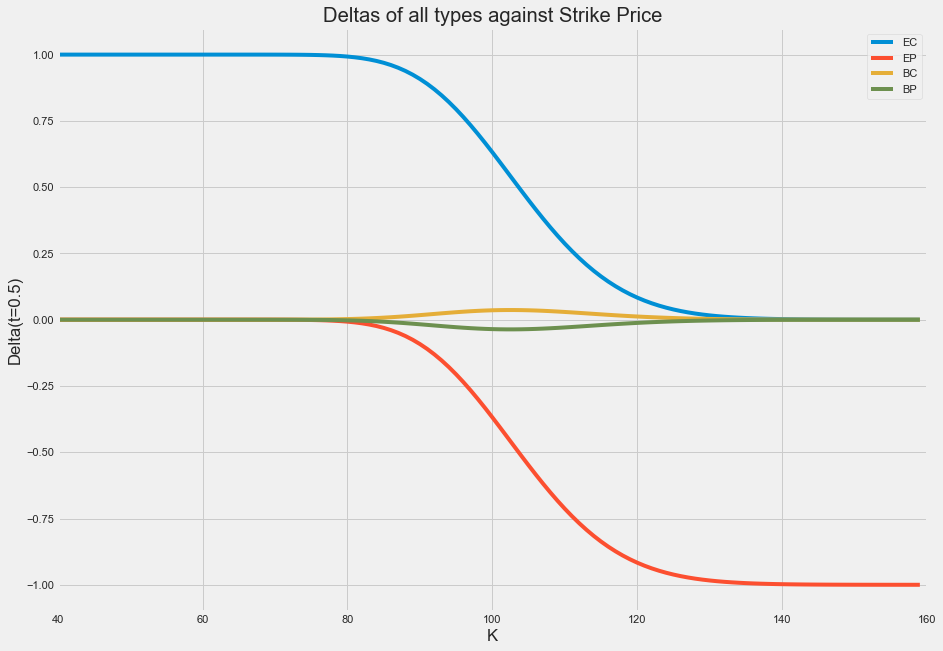

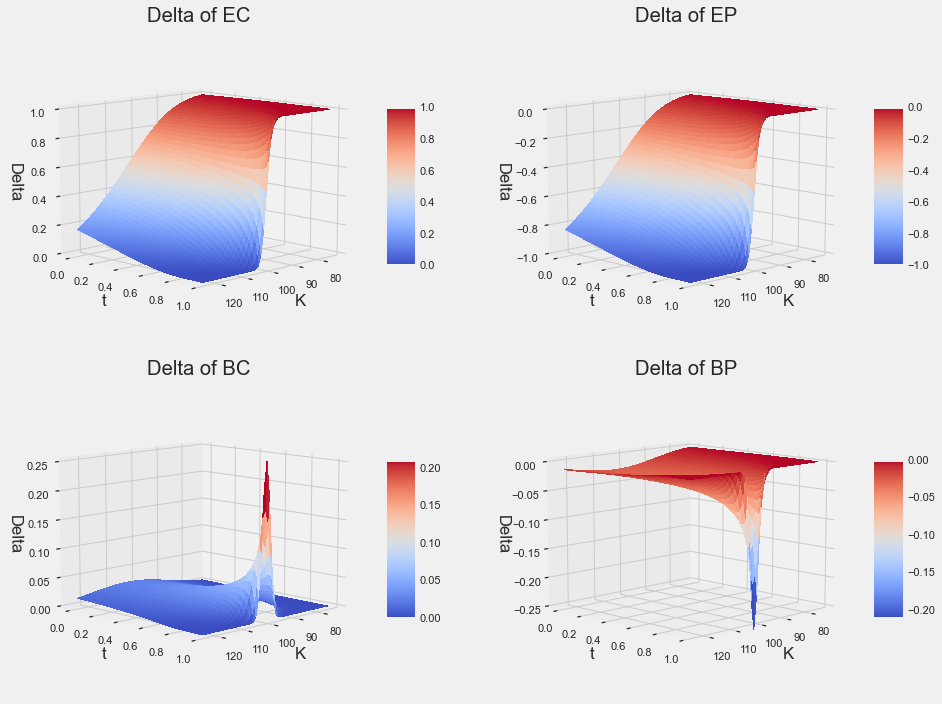

In [9]:
#Choose parameters and values to put into our functions
S=100
r=0.06
q=0
sigma=0.15
T=1

K = np.arange(40, 160, 1)
plt.figure(figsize = (13.88,10))
sns.lineplot(x=K,y=Delta_EC(S,K,r,q,sigma,T,0.5), label = 'EC')
sns.lineplot(x=K,y=Delta_EP(S,K,r,q,sigma,T,0.5), label = 'EP')
sns.lineplot(x=K,y=Delta_BC(S,K,r,q,sigma,T,0.5), label = 'BC')
sns.lineplot(x=K,y=Delta_BP(S,K,r,q,sigma,T,0.5), label = 'BP')

plt.xlabel('K')
plt.ylabel('Delta(t=0.5)')
plt.xlim(40,160)
plt.title('Deltas of all types against Strike Price')

plt.legend()
plt.show()
##########################################################
t = np.arange(0, 1.0, 0.01)
K = np.arange(75,125,1)
t,K = np.meshgrid(t,K)
start = plt.figure(figsize=(15,10))
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=start)
##########################################################
z1= Delta_EC(S,K,r,q,sigma,T,t)

ax1 = start.add_subplot(spec[0, 0], projection='3d')
surf1 = ax1.plot_surface(K, t, z1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax1.set_xlabel('K')
ax1.set_ylabel('t')
ax1.set_zlabel('Delta')
ax1.set_zlim(0, 1)
plt.title("Delta of EC")

start.colorbar(surf1, shrink=0.5, aspect=5)
ax1.view_init(azim=45, elev=10)
##########################################################
z2= Delta_EP(S,K,r,q,sigma,T,t)

ax2 = start.add_subplot(spec[0, 1], projection='3d')
surf2 = ax2.plot_surface(K, t, z2, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax2.set_xlabel('K')
ax2.set_ylabel('t')
ax2.set_zlabel('Delta')
ax2.set_zlim(-1, 0)
plt.title("Delta of EP")

start.colorbar(surf2, shrink=0.5, aspect=5)
ax2.view_init(azim=45, elev=10)
##########################################################
z3= Delta_BC(S,K,r,q,sigma,T,t)

ax3 = start.add_subplot(spec[1, 0], projection='3d')
surf3 = ax3.plot_surface(K, t, z3, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax3.set_xlabel('K')
ax3.set_ylabel('t')
ax3.set_zlabel('Delta')
ax3.set_zlim(0, 0.25)
plt.title("Delta of BC")

start.colorbar(surf3, shrink=0.5, aspect=5)
ax3.view_init(azim=45, elev=10)
##########################################################
z4= Delta_BP(S,K,r,q,sigma,T,t)

ax4 = start.add_subplot(spec[1, 1], projection='3d')
surf4 = ax4.plot_surface(K, t, z4, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax4.set_xlabel('K')
ax4.set_ylabel('t')
ax4.set_zlabel('Delta')
ax4.set_zlim(-0.25, 0)
plt.title("Delta of BP")

start.colorbar(surf4, shrink=0.5, aspect=5)
ax4.view_init(azim=45, elev=10)

start.tight_layout()
plt.show()

## Graphing Gammas of European and Binary Calls/Puts

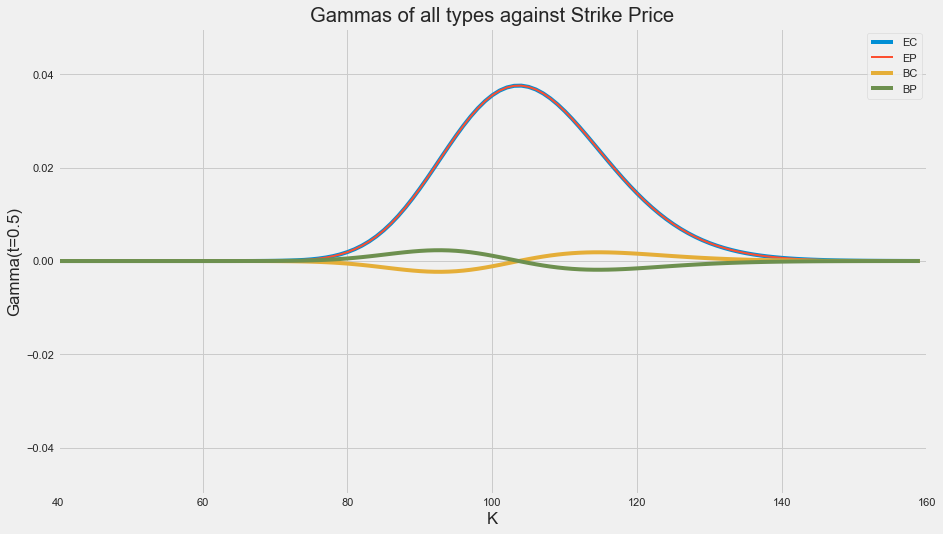

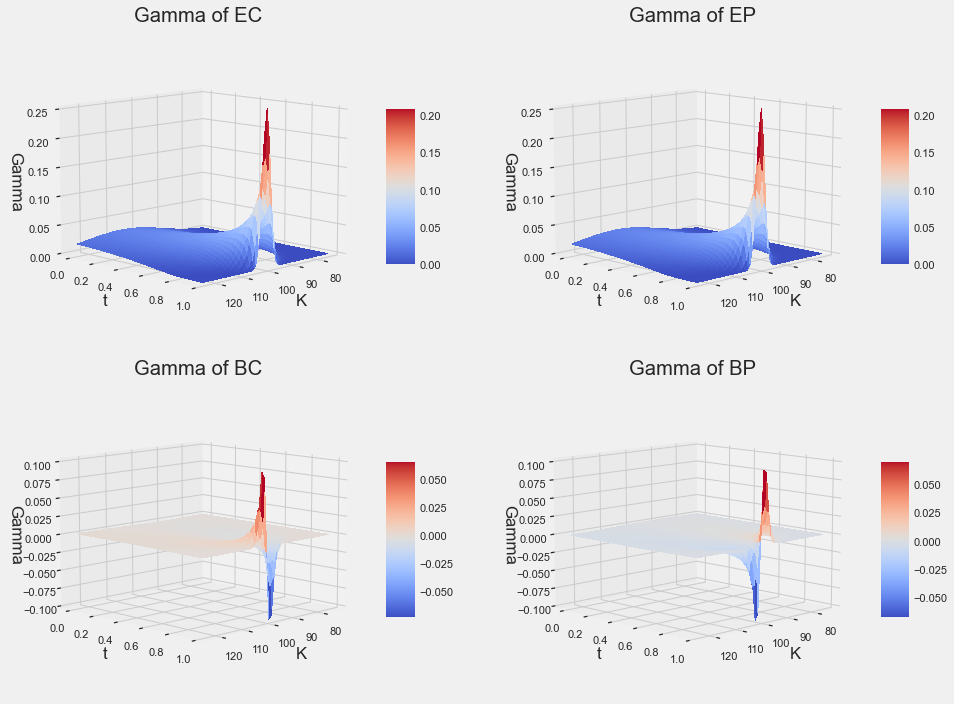

In [10]:
#Choose parameters and values to put into our functions
S=100
r=0.06
q=0
sigma=0.15
T=1

K = np.arange(40, 160, 1)
plt.figure(figsize = (13.88,8))
sns.lineplot(x=K,y=Gamma_EC(S,K,r,q,sigma,T,0.5), label = 'EC')
sns.lineplot(x=K,y=Gamma_EP(S,K,r,q,sigma,T,0.5), label = 'EP', linewidth=2)
sns.lineplot(x=K,y=Gamma_BC(S,K,r,q,sigma,T,0.5), label = 'BC')
sns.lineplot(x=K,y=Gamma_BP(S,K,r,q,sigma,T,0.5), label = 'BP')

plt.xlabel('K')
plt.ylabel('Gamma(t=0.5)')
plt.xlim(40,160)
plt.ylim(-0.05,0.05)
plt.title('Gammas of all types against Strike Price')

plt.legend()
plt.show()
##########################################################
t = np.arange(0, 1.0, 0.01)
K = np.arange(75,125,1)
t,K = np.meshgrid(t,K)
start = plt.figure(figsize=(15,10))
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=start)
##########################################################
z1= Gamma_EC(S,K,r,q,sigma,T,t)

ax1 = start.add_subplot(spec[0, 0], projection='3d')
surf1 = ax1.plot_surface(K, t, z1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax1.set_xlabel('K')
ax1.set_ylabel('t')
ax1.set_zlabel('Gamma')
ax1.set_zlim(0, 0.25)
plt.title("Gamma of EC")

start.colorbar(surf1, shrink=0.5, aspect=5)
ax1.view_init(azim=45, elev=10)
##########################################################
z2= Gamma_EP(S,K,r,q,sigma,T,t)

ax2 = start.add_subplot(spec[0, 1], projection='3d')
surf2 = ax2.plot_surface(K, t, z2, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax2.set_xlabel('K')
ax2.set_ylabel('t')
ax2.set_zlabel('Gamma')
ax2.set_zlim(0, 0.25)
plt.title("Gamma of EP")

start.colorbar(surf2, shrink=0.5, aspect=5)
ax2.view_init(azim=45, elev=10)
##########################################################
z3= Gamma_BC(S,K,r,q,sigma,T,t)

ax3 = start.add_subplot(spec[1, 0], projection='3d')
surf3 = ax3.plot_surface(K, t, z3, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax3.set_xlabel('K')
ax3.set_ylabel('t')
ax3.set_zlabel('Gamma')
ax3.set_zlim(-0.1, 0.1)
plt.title("Gamma of BC")

start.colorbar(surf3, shrink=0.5, aspect=5)
ax3.view_init(azim=45, elev=10)
##########################################################
z4= Gamma_BP(S,K,r,q,sigma,T,t)

ax4 = start.add_subplot(spec[1, 1], projection='3d')
surf4 = ax4.plot_surface(K, t, z4, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax4.set_xlabel('K')
ax4.set_ylabel('t')
ax4.set_zlabel('Gamma')
ax4.set_zlim(-0.1, 0.1)
plt.title("Gamma of BP")

start.colorbar(surf4, shrink=0.5, aspect=5)
ax4.view_init(azim=45, elev=10)

start.tight_layout()
plt.show()

## Graphing Speeds of European and Binary Calls/Puts

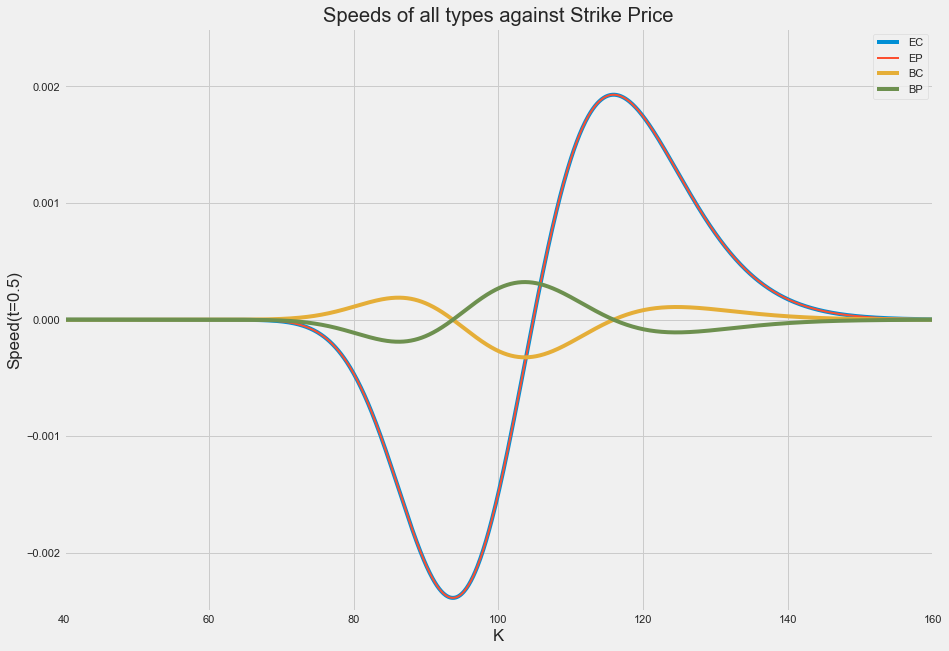

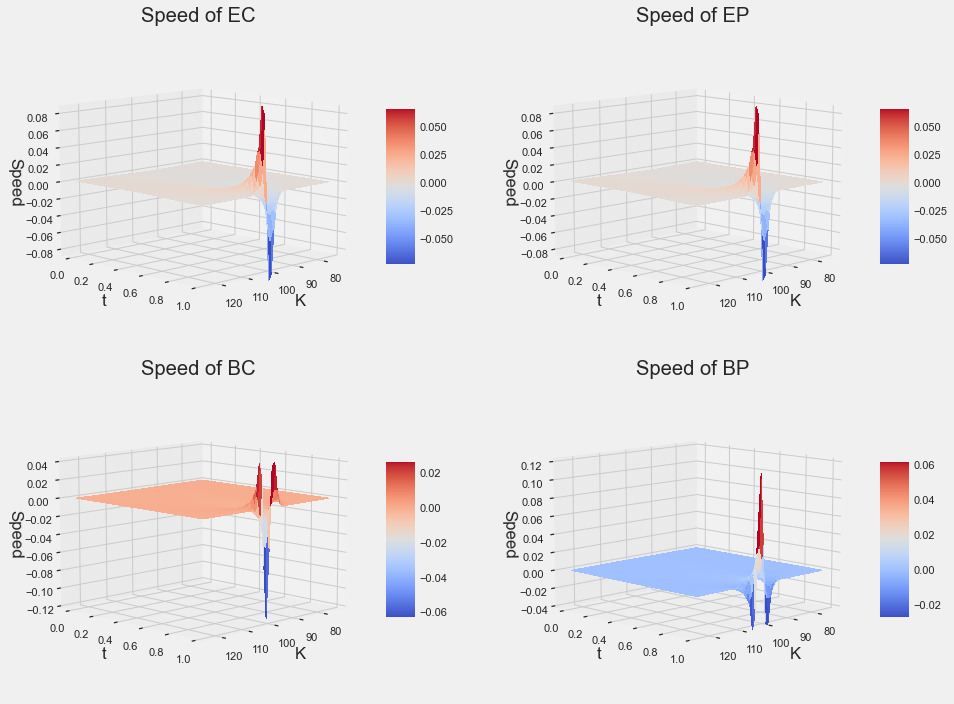

In [11]:
#Choose parameters and values to put into our functions
S=100
r=0.06
q=0
sigma=0.15
T=1

K = np.arange(40, 160, 0.1)
plt.figure(figsize = (13.88,10))
sns.lineplot(x=K,y=Speed_EC(S,K,r,q,sigma,T,0.5), label = 'EC')
sns.lineplot(x=K,y=Speed_EP(S,K,r,q,sigma,T,0.5), label = 'EP', linewidth=2)
sns.lineplot(x=K,y=Speed_BC(S,K,r,q,sigma,T,0.5), label = 'BC')
sns.lineplot(x=K,y=Speed_BP(S,K,r,q,sigma,T,0.5), label = 'BP')

plt.xlabel('K')
plt.ylabel('Speed(t=0.5)')
plt.xlim(40,160)
plt.ylim(-0.0025,0.0025)
plt.title('Speeds of all types against Strike Price')

plt.legend()
plt.show()
##########################################################
t = np.arange(0, 1.0, 0.01)
K = np.arange(75,125,1)
t,K = np.meshgrid(t,K)
start = plt.figure(figsize=(15,10))
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=start)
##########################################################
z1= Speed_EC(S,K,r,q,sigma,T,t)

ax1 = start.add_subplot(spec[0, 0], projection='3d')
surf1 = ax1.plot_surface(K, t, z1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax1.set_xlabel('K')
ax1.set_ylabel('t')
ax1.set_zlabel('Speed')
ax1.set_zlim(-0.085, 0.085)
plt.title("Speed of EC")

start.colorbar(surf1, shrink=0.5, aspect=5)
ax1.view_init(azim=45, elev=10)
##########################################################
z2= Speed_EP(S,K,r,q,sigma,T,t)

ax2 = start.add_subplot(spec[0, 1], projection='3d')
surf2 = ax2.plot_surface(K, t, z2, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax2.set_xlabel('K')
ax2.set_ylabel('t')
ax2.set_zlabel('Speed')
ax2.set_zlim(-0.085, 0.085)
plt.title("Speed of EP")

start.colorbar(surf2, shrink=0.5, aspect=5)
ax2.view_init(azim=45, elev=10)
##########################################################
z3= Speed_BC(S,K,r,q,sigma,T,t)

ax3 = start.add_subplot(spec[1, 0], projection='3d')
surf3 = ax3.plot_surface(K, t, z3, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax3.set_xlabel('K')
ax3.set_ylabel('t')
ax3.set_zlabel('Speed')
ax3.set_zlim(-0.12, 0.04)
plt.title("Speed of BC")

start.colorbar(surf3, shrink=0.5, aspect=5)
ax3.view_init(azim=45, elev=10)
##########################################################
z4= Speed_BP(S,K,r,q,sigma,T,t)

ax4 = start.add_subplot(spec[1, 1], projection='3d')
surf4 = ax4.plot_surface(K, t, z4, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax4.set_xlabel('K')
ax4.set_ylabel('t')
ax4.set_zlabel('Speed')
ax4.set_zlim(-0.04, 0.12)
plt.title("Speed of BP")

start.colorbar(surf4, shrink=0.5, aspect=5)
ax4.view_init(azim=45, elev=10)

start.tight_layout()
plt.show()

## Graphing Thetas of European and Binary Calls/Puts

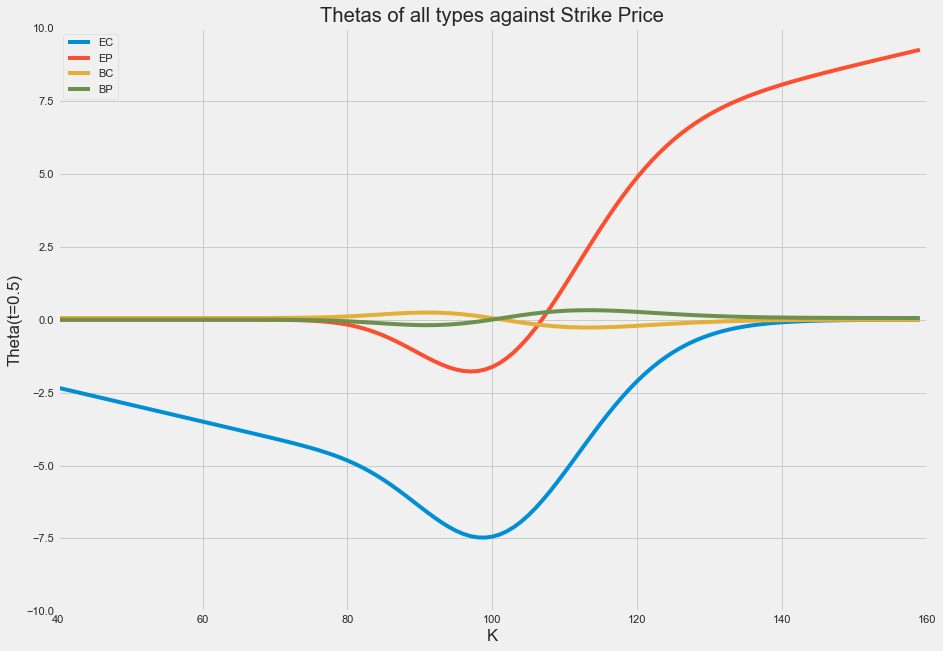

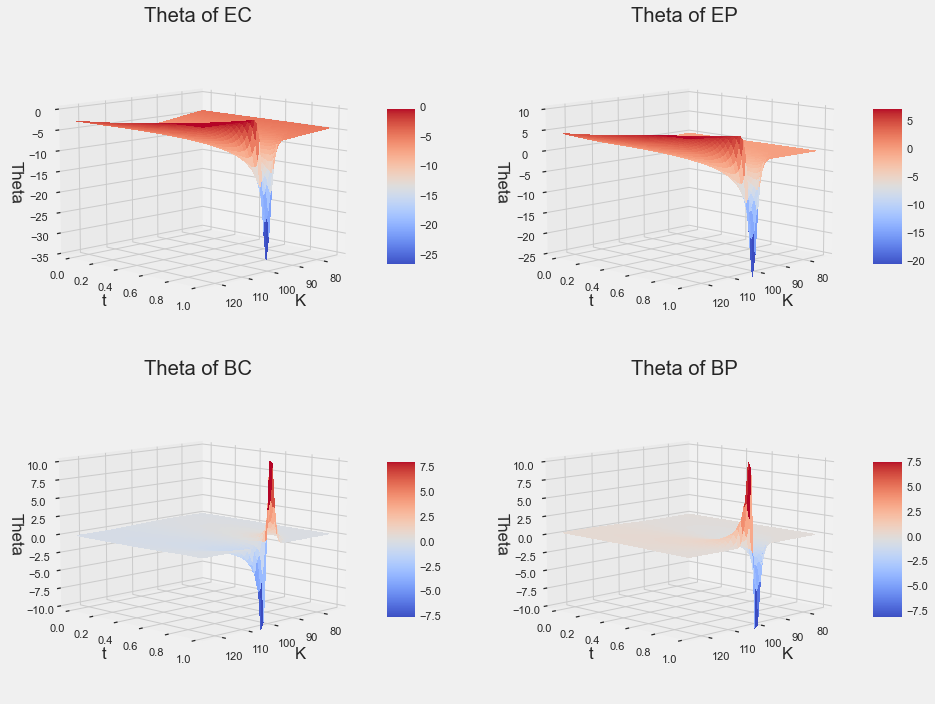

In [12]:
#Choose parameters and values to put into our functions
S=100
r=0.06
q=0
sigma=0.15
T=1

K = np.arange(40, 160, 1)
plt.figure(figsize = (13.88,10))
sns.lineplot(x=K,y=Theta_EC(S,K,r,q,sigma,T,0.5), label = 'EC')
sns.lineplot(x=K,y=Theta_EP(S,K,r,q,sigma,T,0.5), label = 'EP')
sns.lineplot(x=K,y=Theta_BC(S,K,r,q,sigma,T,0.5), label = 'BC')
sns.lineplot(x=K,y=Theta_BP(S,K,r,q,sigma,T,0.5), label = 'BP')

plt.xlabel('K')
plt.ylabel('Theta(t=0.5)')
plt.xlim(40,160)
plt.ylim(-10,10)
plt.title('Thetas of all types against Strike Price')

plt.legend()
plt.show()
##########################################################
t = np.arange(0, 1.0, 0.01)
K = np.arange(75,125,1)
t,K = np.meshgrid(t,K)
start = plt.figure(figsize=(15,10))
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=start)
##########################################################
z1= Theta_EC(S,K,r,q,sigma,T,t)

ax1 = start.add_subplot(spec[0, 0], projection='3d')
surf1 = ax1.plot_surface(K, t, z1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax1.set_xlabel('K')
ax1.set_ylabel('t')
ax1.set_zlabel('Theta')
ax1.set_zlim(-35, 0)
plt.title("Theta of EC")

start.colorbar(surf1, shrink=0.5, aspect=5)
ax1.view_init(azim=45, elev=10)
##########################################################
z2= Theta_EP(S,K,r,q,sigma,T,t)

ax2 = start.add_subplot(spec[0, 1], projection='3d')
surf2 = ax2.plot_surface(K, t, z2, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax2.set_xlabel('K')
ax2.set_ylabel('t')
ax2.set_zlabel('Theta')
ax2.set_zlim(-25, 10)
plt.title("Theta of EP")

start.colorbar(surf2, shrink=0.5, aspect=5)
ax2.view_init(azim=45, elev=10)
##########################################################
z3= Theta_BC(S,K,r,q,sigma,T,t)

ax3 = start.add_subplot(spec[1, 0], projection='3d')
surf3 = ax3.plot_surface(K, t, z3, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax3.set_xlabel('K')
ax3.set_ylabel('t')
ax3.set_zlabel('Theta')
ax3.set_zlim(-10, 10)
plt.title("Theta of BC")

start.colorbar(surf3, shrink=0.5, aspect=5)
ax3.view_init(azim=45, elev=10)
##########################################################
z4= Theta_BP(S,K,r,q,sigma,T,t)

ax4 = start.add_subplot(spec[1, 1], projection='3d')
surf4 = ax4.plot_surface(K, t, z4, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax4.set_xlabel('K')
ax4.set_ylabel('t')
ax4.set_zlabel('Theta')
ax4.set_zlim(-10, 10)
plt.title("Theta of BP")

start.colorbar(surf4, shrink=0.5, aspect=5)
ax4.view_init(azim=45, elev=10)

start.tight_layout()
plt.show()

## Graphing Vegas of European and Binary Calls/Puts

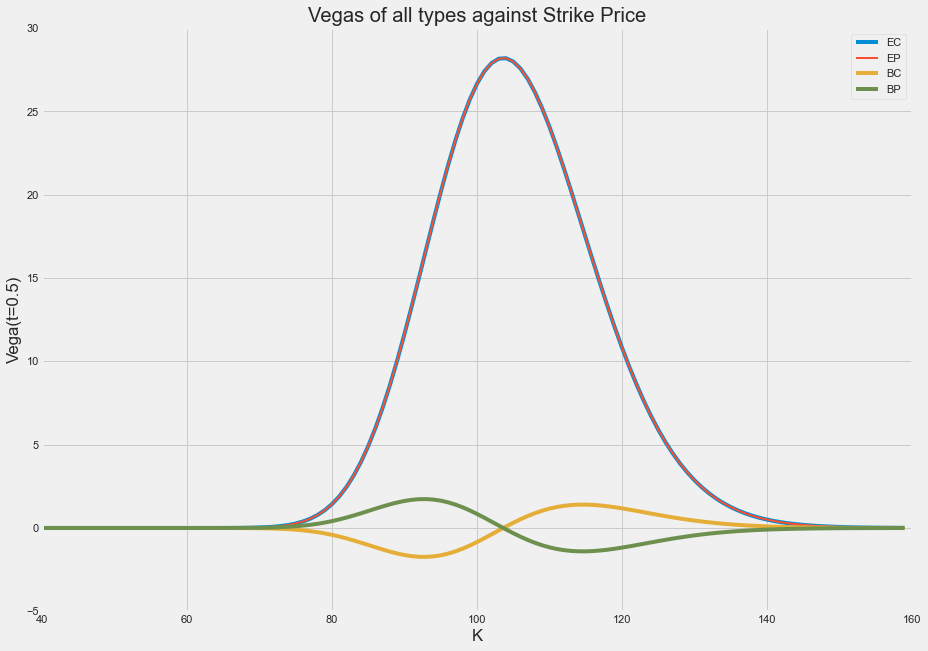

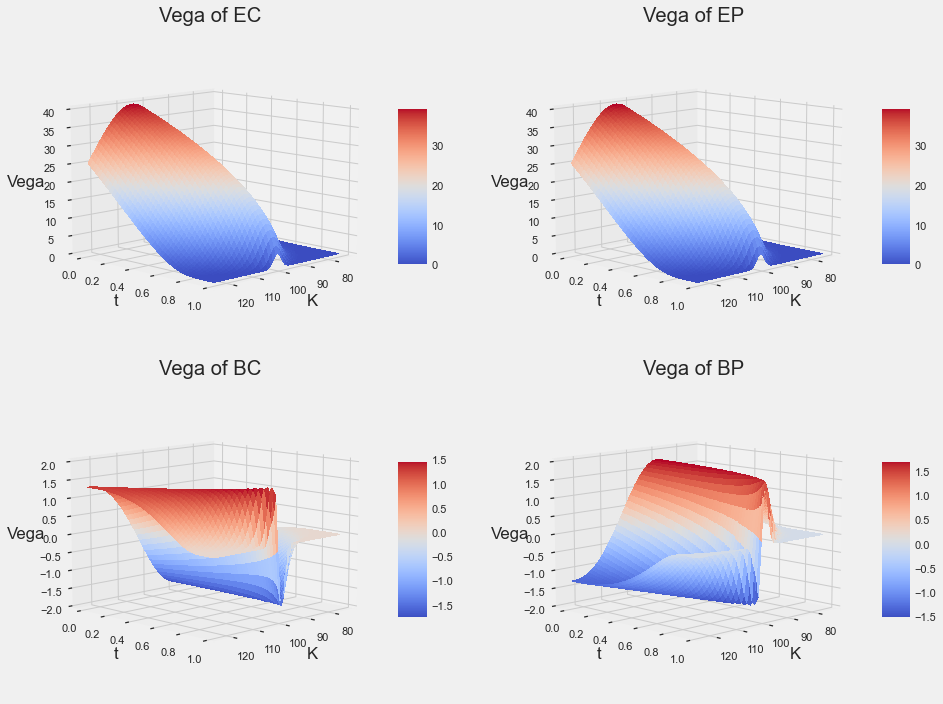

In [13]:
#Choose parameters and values to put into our functions
S=100
r=0.06
q=0
sigma=0.15
T=1

K = np.arange(40, 160, 1)
plt.figure(figsize = (13.88,10))
sns.lineplot(x=K,y=Vega_EC(S,K,r,q,sigma,T,0.5), label = 'EC')
sns.lineplot(x=K,y=Vega_EP(S,K,r,q,sigma,T,0.5), label = 'EP', linewidth=2)
sns.lineplot(x=K,y=Vega_BC(S,K,r,q,sigma,T,0.5), label = 'BC')
sns.lineplot(x=K,y=Vega_BP(S,K,r,q,sigma,T,0.5), label = 'BP')

plt.xlabel('K')
plt.ylabel('Vega(t=0.5)')
plt.xlim(40,160)
plt.ylim(-5,30)
plt.title('Vegas of all types against Strike Price')

plt.legend()
plt.show()
##########################################################
t = np.arange(0, 1.0, 0.01)
K = np.arange(75,125,1)
t,K = np.meshgrid(t,K)
start = plt.figure(figsize=(15,10))
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=start)
##########################################################
z1= Vega_EC(S,K,r,q,sigma,T,t)

ax1 = start.add_subplot(spec[0, 0], projection='3d')
surf1 = ax1.plot_surface(K, t, z1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax1.set_xlabel('K')
ax1.set_ylabel('t')
ax1.set_zlabel('Vega')
ax1.set_zlim(0, 40)
plt.title("Vega of EC")

start.colorbar(surf1, shrink=0.5, aspect=5)
ax1.view_init(azim=45, elev=10)
##########################################################
z2= Vega_EP(S,K,r,q,sigma,T,t)

ax2 = start.add_subplot(spec[0, 1], projection='3d')
surf2 = ax2.plot_surface(K, t, z2, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax2.set_xlabel('K')
ax2.set_ylabel('t')
ax2.set_zlabel('Vega')
ax2.set_zlim(0, 40)
plt.title("Vega of EP")

start.colorbar(surf2, shrink=0.5, aspect=5)
ax2.view_init(azim=45, elev=10)
##########################################################
z3= Vega_BC(S,K,r,q,sigma,T,t)

ax3 = start.add_subplot(spec[1, 0], projection='3d')
surf3 = ax3.plot_surface(K, t, z3, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax3.set_xlabel('K')
ax3.set_ylabel('t')
ax3.set_zlabel('Vega')
ax3.set_zlim(-2, 2)
plt.title("Vega of BC")

start.colorbar(surf3, shrink=0.5, aspect=5)
ax3.view_init(azim=45, elev=10)
##########################################################
z4= Vega_BP(S,K,r,q,sigma,T,t)

ax4 = start.add_subplot(spec[1, 1], projection='3d')
surf4 = ax4.plot_surface(K, t, z4, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax4.set_xlabel('K')
ax4.set_ylabel('t')
ax4.set_zlabel('Vega')
ax4.set_zlim(-2, 2)
plt.title("Vega of BP")

start.colorbar(surf4, shrink=0.5, aspect=5)
ax4.view_init(azim=45, elev=10)

start.tight_layout()
plt.show()

## Graphing Rhos of European and Binary Calls/Puts

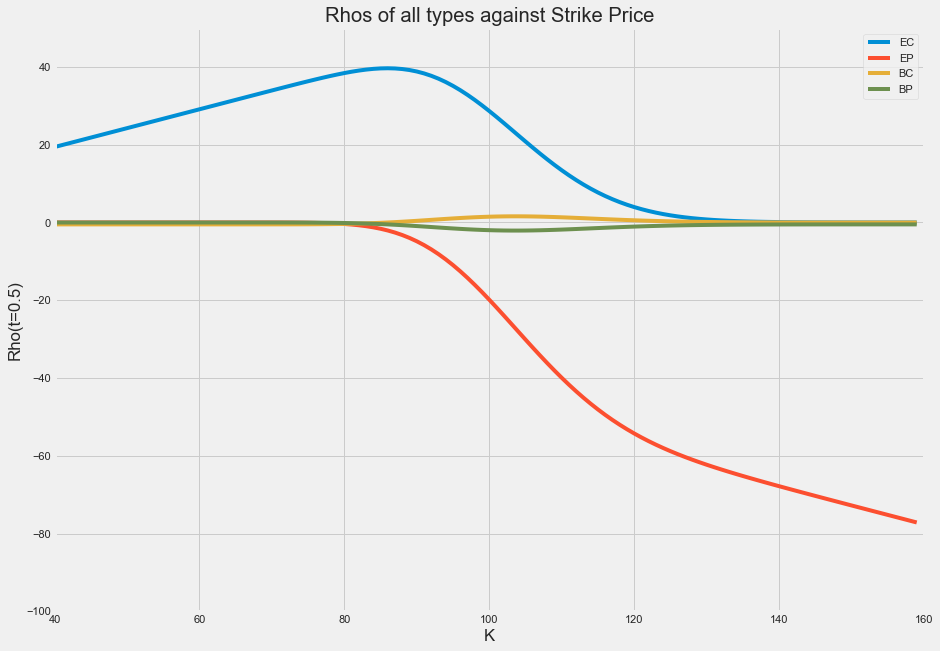

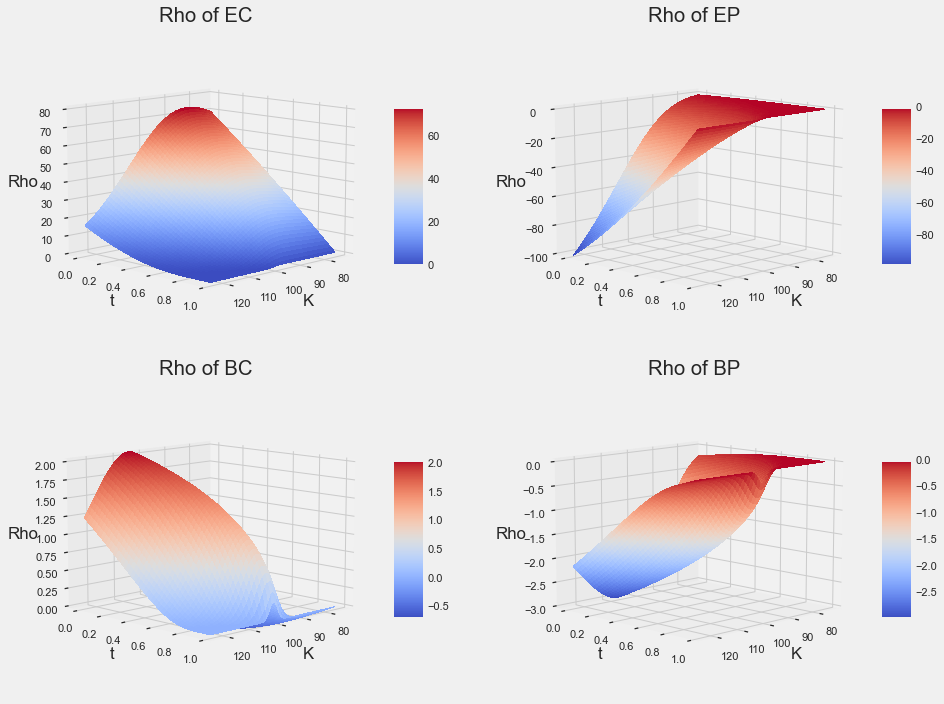

In [14]:
#Choose parameters and values to put into our functions
S=100
r=0.06
q=0
sigma=0.15
T=1

K = np.arange(40, 160, 1)
plt.figure(figsize = (13.88,10))
sns.lineplot(x=K,y=Rho_EC(S,K,r,q,sigma,T,0.5), label = 'EC')
sns.lineplot(x=K,y=Rho_EP(S,K,r,q,sigma,T,0.5), label = 'EP')
sns.lineplot(x=K,y=Rho_BC(S,K,r,q,sigma,T,0.5), label = 'BC')
sns.lineplot(x=K,y=Rho_BP(S,K,r,q,sigma,T,0.5), label = 'BP')

plt.xlabel('K')
plt.ylabel('Rho(t=0.5)')
plt.xlim(40,160)
plt.ylim(-100,50)
plt.title('Rhos of all types against Strike Price')

plt.legend()
plt.show()
##########################################################
t = np.arange(0, 1.0, 0.01)
K = np.arange(75,125,1)
t,K = np.meshgrid(t,K)
start = plt.figure(figsize=(15,10))
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=start)
##########################################################
z1= Rho_EC(S,K,r,q,sigma,T,t)

ax1 = start.add_subplot(spec[0, 0], projection='3d')
surf1 = ax1.plot_surface(K, t, z1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax1.set_xlabel('K')
ax1.set_ylabel('t')
ax1.set_zlabel('Rho')
ax1.set_zlim(0, 80)
plt.title("Rho of EC")

start.colorbar(surf1, shrink=0.5, aspect=5)
ax1.view_init(azim=45, elev=10)
##########################################################
z2= Rho_EP(S,K,r,q,sigma,T,t)

ax2 = start.add_subplot(spec[0, 1], projection='3d')
surf2 = ax2.plot_surface(K, t, z2, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax2.set_xlabel('K')
ax2.set_ylabel('t')
ax2.set_zlabel('Rho')
ax2.set_zlim(-100, 0)
plt.title("Rho of EP")

start.colorbar(surf2, shrink=0.5, aspect=5)
ax2.view_init(azim=45, elev=10)
##########################################################
z3= Rho_BC(S,K,r,q,sigma,T,t)

ax3 = start.add_subplot(spec[1, 0], projection='3d')
surf3 = ax3.plot_surface(K, t, z3, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax3.set_xlabel('K')
ax3.set_ylabel('t')
ax3.set_zlabel('Rho')
ax3.set_zlim(0, 2)
plt.title("Rho of BC")

start.colorbar(surf3, shrink=0.5, aspect=5)
ax3.view_init(azim=45, elev=10)
##########################################################
z4= Rho_BP(S,K,r,q,sigma,T,t)

ax4 = start.add_subplot(spec[1, 1], projection='3d')
surf4 = ax4.plot_surface(K, t, z4, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ax4.set_xlabel('K')
ax4.set_ylabel('t')
ax4.set_zlabel('Rho')
ax4.set_zlim(-3, 0)
plt.title("Rho of BP")

start.colorbar(surf4, shrink=0.5, aspect=5)
ax4.view_init(azim=45, elev=10)

start.tight_layout()
plt.show()